# Predicción de Dirección Financiera de TSLA mediante Redes Neuronales
---


## **Codigo de preprocesamiento y analisis exploratorio**
---

## Librerias




In [1]:
#Librerias Fase1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import yfinance as yf


In [2]:
#Librerias Fase2
from sklearn.preprocessing import MinMaxScaler

In [3]:
#Librerias Fase3
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
df = yf.download(
    "TSLA",
    start="2015-01-01",
    end="2025-12-31"
)

display(df.head())

/tmp/ipykernel_4514/3215566705.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


In [5]:
#Graficas
def plotTimeSeries(dataframe, column, title, plotType='line', startDate=None, endDate=None, xLabel='Fecha', yLabel='Valor', figureSize=(14, 6)):

    filteredData = dataframe.copy()

    if startDate is not None:
        filteredData = filteredData[filteredData.index >= startDate]

    if endDate is not None:
        filteredData = filteredData[filteredData.index <= endDate]

    seriesData = filteredData[column].squeeze()

    plt.figure(figsize=figureSize)

    if plotType == 'line':
        plt.plot(filteredData.index, seriesData)

    elif plotType == 'bar':
        plt.bar(filteredData.index, seriesData)

    plt.title(title)
    plt.xlabel(xLabel)
    plt.ylabel(yLabel)
    plt.grid(True)

    plt.show()

In [6]:
def createTimeSeries(caracteristicasData, targetData, sequenceLength=30):

    X = []
    y = []

    for i in range(sequenceLength, len(caracteristicasData)):

        X.append(caracteristicasData[i-sequenceLength:i])
        y.append(targetData[i])

    return np.array(X), np.array(y)

In [7]:
def createTimeSeriesBatches(caracteristicasData, targetData, sequenceLength=30, batchSize=32):

    X, y = createTimeSeries(caracteristicasData=caracteristicasData, targetData=targetData, sequenceLength=sequenceLength)

    XBatches = []
    yBatches = []

    for i in range(0, len(X), batchSize):

        XBatches.append(X[i:i+batchSize])
        yBatches.append(y[i:i+batchSize])

    return XBatches, yBatches

## Verificacion de valores faltantes y/o repetidos

In [8]:
print("\nValores faltantes:")
print(df.isnull().sum())
print("\nDuplicados:")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)


Valores faltantes:
Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64

Duplicados:
0


## Graficas de series de precio, volumen

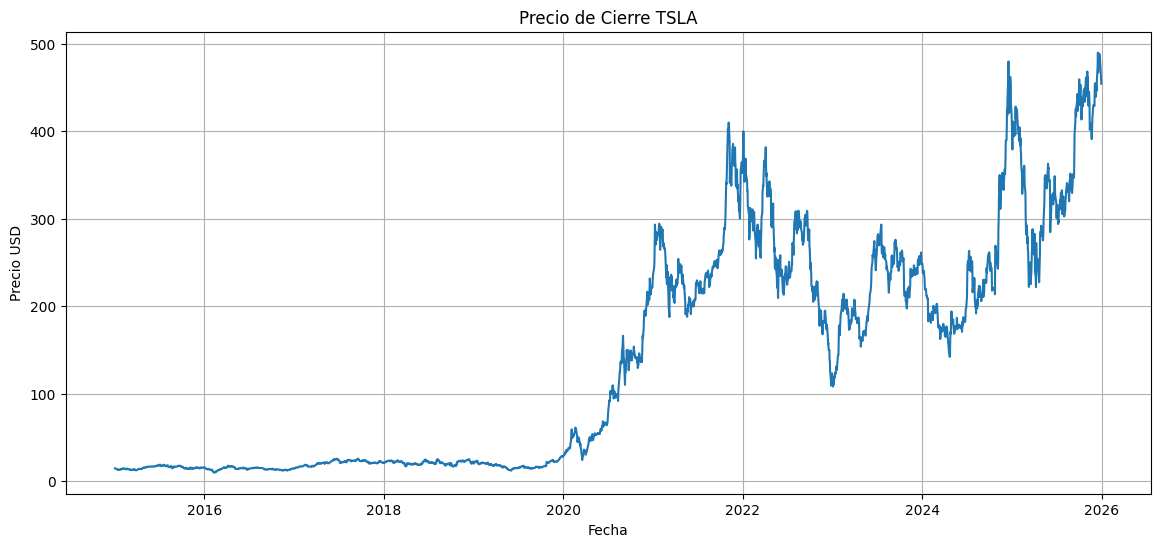

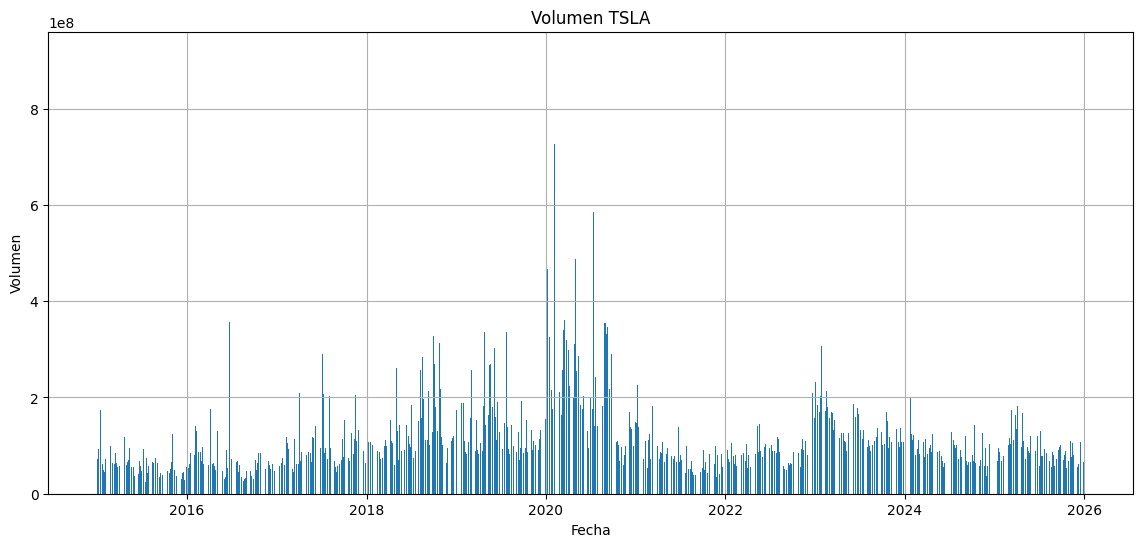

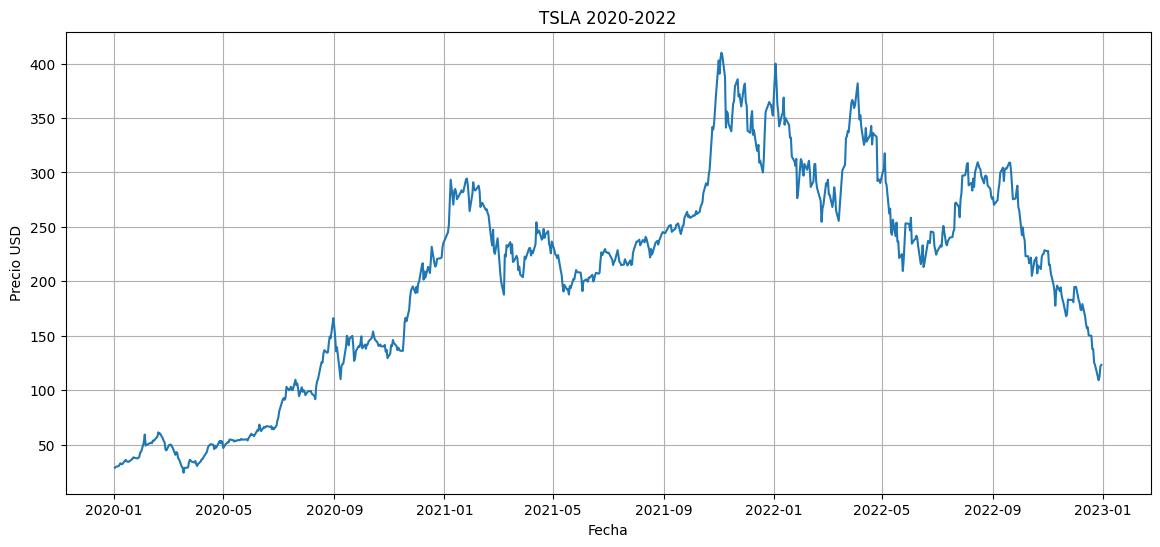

In [9]:
plotTimeSeries( dataframe=df,column='Close',title='Precio de Cierre TSLA',plotType='line',yLabel='Precio USD')
plotTimeSeries(dataframe=df,column='Volume',title='Volumen TSLA',plotType='bar',yLabel='Volumen')
plotTimeSeries(dataframe=df,column='Close',title='TSLA 2020-2022',plotType='line',startDate='2020-01-01',endDate='2022-12-31',yLabel='Precio USD')



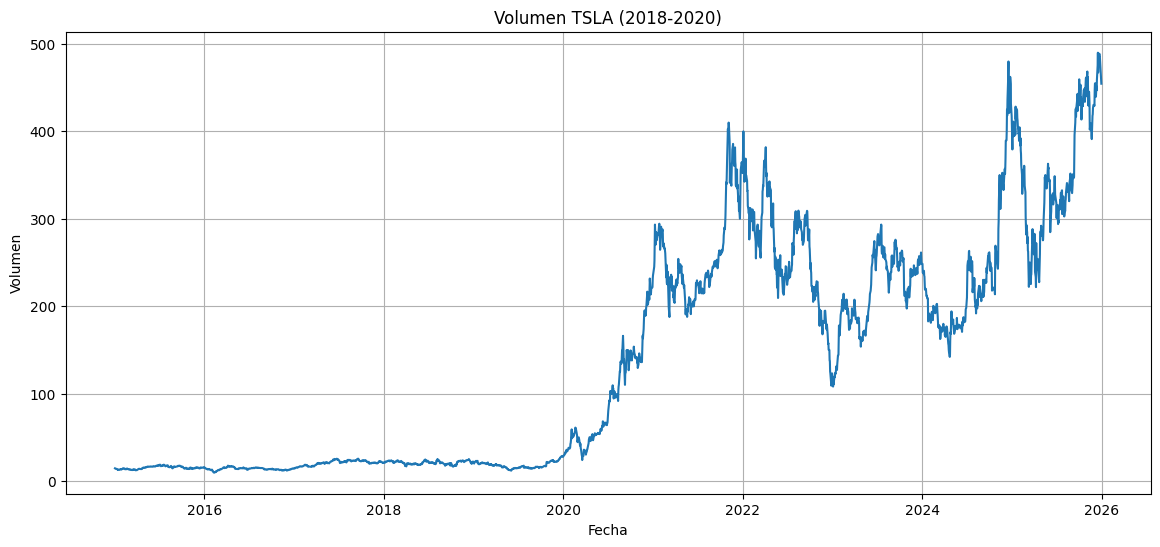

In [10]:
plotTimeSeries(dataframe=df,column='Close',title='Volumen TSLA (2018-2020)',startDate=None,endDate=None,yLabel='Volumen')

## Estadisticas descriptivas

In [11]:
print("\nEstadísticas descriptivas:")
print(df.describe())


Estadísticas descriptivas:
Price         Close         High          Low         Open        Volume
Ticker         TSLA         TSLA         TSLA         TSLA          TSLA
count   2765.000000  2765.000000  2765.000000  2765.000000  2.765000e+03
mean     137.375190   140.420256   134.183493   137.400250  1.110144e+08
std      130.645336   133.575996   127.620236   130.736915  7.152517e+07
min        9.578000    10.331333     9.403333     9.488000  1.062000e+07
25%       17.844667    18.072666    17.544001    17.825333  6.772660e+07
50%       71.987335    72.512665    66.915337    67.518669  9.286200e+07
75%      241.029999   247.000000   236.449997   241.809998  1.284645e+08
max      489.880005   498.829987   485.329987   489.880005  9.140820e+08


In [12]:
print('Valor inicial df:',df.index.min())
print('valor final df  :',df.index.max())
print('Columnas df     :',df.columns)

Valor inicial df: 2015-01-02 00:00:00
valor final df  : 2025-12-30 00:00:00
Columnas df     : MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])


## Preprocesamiento para generar series de tiempo etiquetas accion sube/ accion baja

In [13]:
caracteristicas  = [ 'Open','High','Low','Close','Volume']

data = df[caracteristicas].copy()


data['SubeBaja'] = np.where(data['Close'].shift(-1) > data['Close'],1,0)
data.dropna(inplace=True)
print(data)

Price             Open        High         Low       Close    Volume SubeBaja
Ticker            TSLA        TSLA        TSLA        TSLA      TSLA         
Date                                                                         
2015-01-02   14.858000   14.883333   14.217333   14.620667  71466000        0
2015-01-05   14.303333   14.433333   13.810667   14.006000  80527500        1
2015-01-06   14.004000   14.280000   13.614000   14.085333  93928500        0
2015-01-07   14.223333   14.318667   13.985333   14.063333  44526000        0
2015-01-08   14.187333   14.253333   14.000667   14.041333  51637500        0
...                ...         ...         ...         ...       ...      ...
2025-12-23  489.399994  491.970001  482.839996  485.559998  58223600        0
2025-12-24  488.480011  490.899994  476.799988  485.399994  41285400        0
2025-12-26  485.230011  489.089996  473.820007  475.190002  58780700        0
2025-12-29  469.000000  469.399994  459.000000  459.640015  6626

In [14]:
scaler = MinMaxScaler(feature_range=(0,1))

caracteristicasEscaladas = scaler.fit_transform(data[caracteristicas])

In [15]:
X, y = createTimeSeries(caracteristicasData=caracteristicasEscaladas, targetData=data['SubeBaja'].values, sequenceLength=30)
print(X.shape)
print(y.shape)

(2735, 30, 5)
(2735,)


In [16]:
# print(X[0])


In [17]:
XBatches, yBatches = createTimeSeriesBatches(caracteristicasData=caracteristicasEscaladas, targetData=data['SubeBaja'].values, sequenceLength=30, batchSize=32)

print(len(XBatches))
print(XBatches[0].shape)
print(yBatches[0].shape)

86
(32, 30, 5)
(32,)


In [39]:
# Graficas
def plotBatchTargetDistribution(yBatch, title='Distribución Batch'):

    values, counts = np.unique(yBatch,return_counts=True)
    plt.figure(figsize=(6,4))
    plt.bar(values.astype(str), counts)
    plt.title(title)
    plt.xlabel('Clase')
    plt.ylabel('Cantidad')
    plt.grid(True)
    plt.show()


def plotLoss(history):

    plt.figure(figsize=(10,5))

    plt.plot(
        history.history['loss'],
        label='Train Loss'
    )

    plt.plot(
        history.history['val_loss'],
        label='Validation Loss'
    )

    plt.legend()

    plt.title('Evolución de Loss')

    plt.show()

def plotPredictionVsReal(yReal, yPred):
    plt.figure(figsize=(12,6))
    plt.plot(yReal, label='Valor Real')
    plt.plot(yPred, label='Predicción')
    plt.legend()
    plt.title('Predicción vs Real')
    plt.show()

# Distribucion de clases

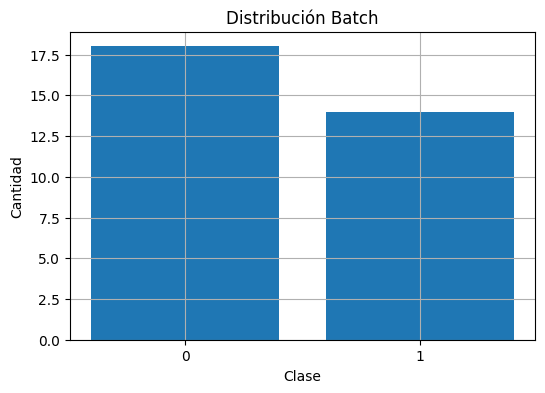

In [19]:
plotBatchTargetDistribution(yBatches[0])

In [20]:
def plotHistogram(data, title):

    plt.figure(figsize=(8,5))
    plt.hist(data, bins=30)
    plt.title(title)
    plt.grid(True)
    plt.show()

## Histograma de distribucion de precio cierre y volumenes

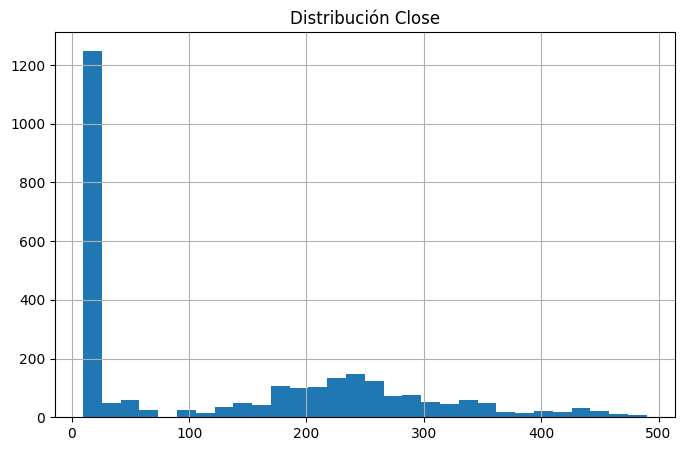

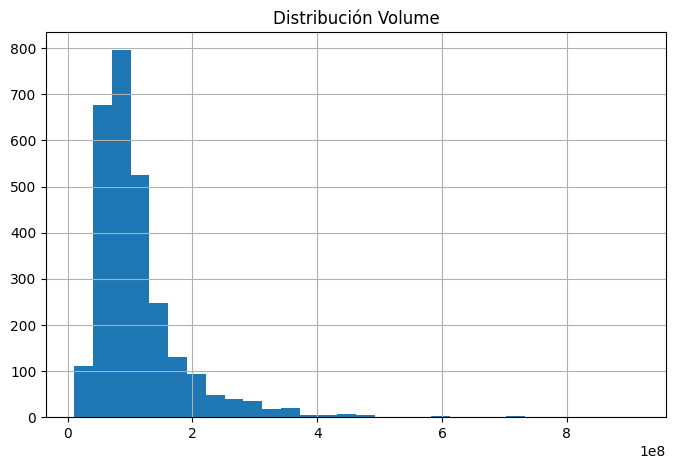

In [21]:
plotHistogram(data['Close'],'Distribución Close')
plotHistogram(data['Volume'],'Distribución Volume')

Como era de esperarse por ser series financieras de acciones los datos No son gauseanos y tiene cola pesadas y volatilidad agrupada.

In [22]:
def plotDensity(data, title, figureSize=(8,5)):
    seriesData = np.array(data).squeeze()
    pd.Series(seriesData).plot(kind='density',figsize=figureSize)
    plt.title(title)
    plt.grid(True)
    plt.show()

## Grafica de densidad segun precio

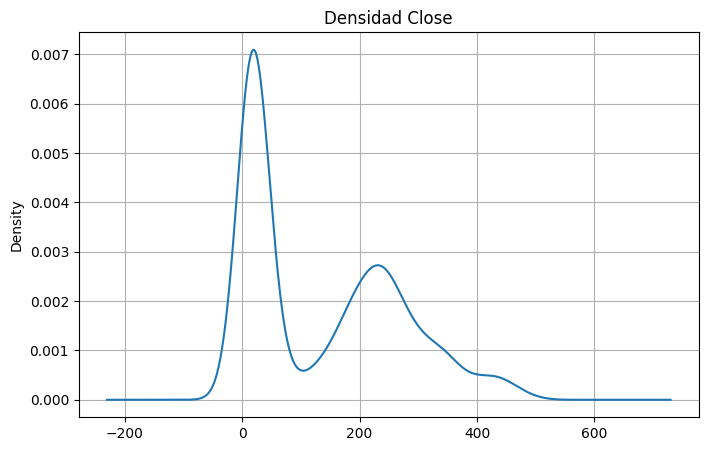

In [23]:
plotDensity(data['Close'],'Densidad Close')

Valores posibles del precio X y la densidad relativa de esos valores en y. Entonces aca podemos visualizar donde se concentran los precios.

## Division de dataset con skelarn

In [24]:
XTrain, XTemp, yTrain, yTemp = train_test_split(X,y,test_size=0.30,shuffle=False)

In [25]:
XValidation, XTest, yValidation, yTest = train_test_split(XTemp,yTemp,test_size=0.50,shuffle=False)

In [26]:
print("Train:", XTrain.shape)
print("Validation:", XValidation.shape)
print("Test:", XTest.shape)

Train: (1914, 30, 5)
Validation: (410, 30, 5)
Test: (411, 30, 5)


## Definicion del modelo

In [27]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(XTrain.shape[1], XTrain.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Entrenamiento del modelo

In [28]:
model.compile(optimizer='adam', loss='mse')

In [32]:
earlyStopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.2542 - val_loss: 0.2605
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.2545 - val_loss: 0.2524
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.2517 - val_loss: 0.2497
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.2532 - val_loss: 0.2498
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.2528 - val_loss: 0.2498
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.2518 - val_loss: 0.2496
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.2507 - val_loss: 0.2496
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.2532 - val_loss: 0.2523
Epoch 9/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.2513 - val_loss: 0.2507
Epoch 10/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.2528 - val_loss: 0.2495


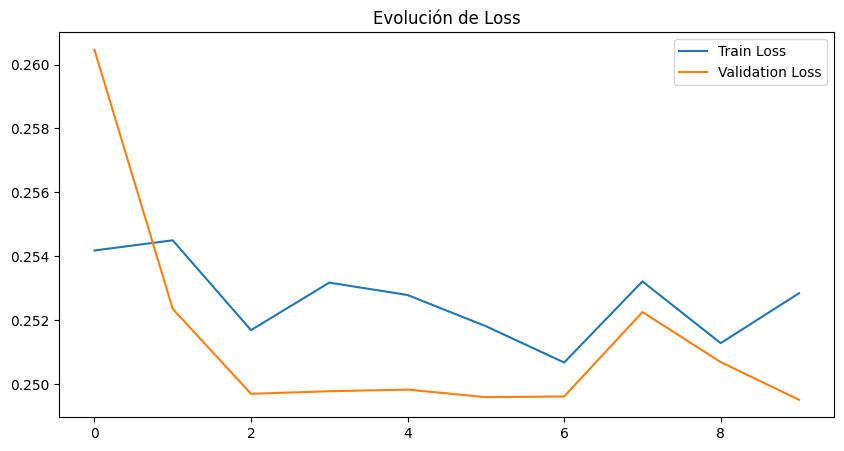

In [35]:
history = model.fit(
    XTrain,
    yTrain,
    validation_data=(XValidation, yValidation),
    epochs=30,
    batch_size=32,
    callbacks=[earlyStopping]
)

plotLoss(history)

#Evaluacion del odelo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
MAE: 0.4973180890083313
RMSE: 0.5152415959775515


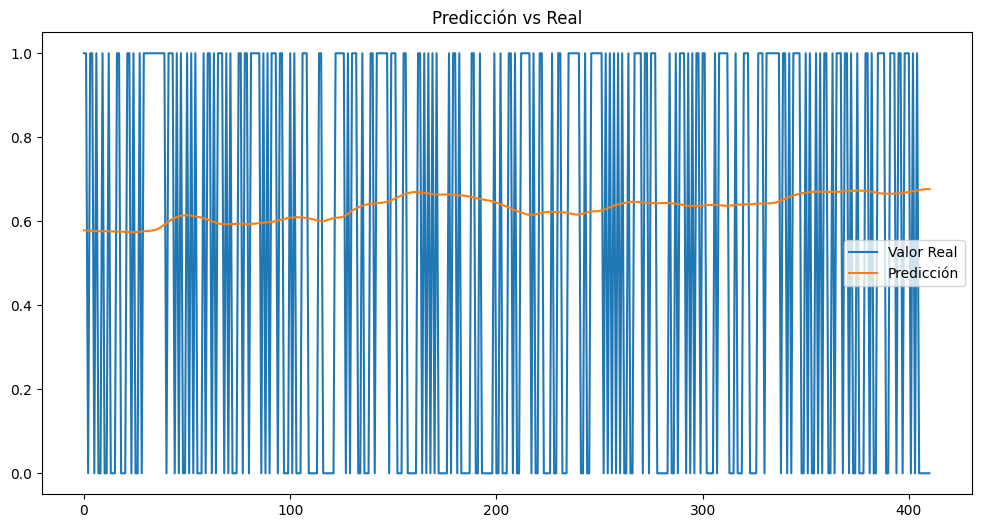

In [40]:
yPred = model.predict(XTest)

mae = mean_absolute_error(yTest, yPred)

rmse = np.sqrt(
    mean_squared_error(yTest, yPred)
)

print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

plotPredictionVsReal(yTest, yPred)

In [41]:
ultimaSecuencia = XTest[-1]

ultimaSecuencia = np.expand_dims(ultimaSecuencia, axis=0)

prediccionFutura = model.predict(ultimaSecuencia)

print("Predicción futura:", prediccionFutura)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step
Predicción futura: [[0.6768391]]
